# Intent spotcheck and trends

Load intent-classified data from `intent_classification.ipynb`, spot-check full conversations per category/sub-category, and analyze temporal trends (weekly intent %, within-week variation, hour-of-day). Timestamps are **UTC**; optional timezone conversion and event annotations are supported.

In [1]:
# Control variables (edit and run first)
INTENT_OUTPUT_DIR = "intent_output"
RUN_SPOTCHECK = True
RUN_WEEKLY_TRENDS = True
RUN_WITHIN_WEEK = True
RUN_HOUR_TRENDS = True
SAMPLE_PER_CATEGORY = 3
BY_MAJOR = True   # spot check by intent_major
BY_SUB = False    # spot check by intent_sub (more categories)
EVENT_DATES = None   # list of (date_str, label) or path to CSV with date, event_name
TIMEZONE = None   # e.g. "US/Pacific" for assumed local hour; None = UTC only

## Load data

Load classified parquet and ensure conversation column is parsed (list-of-dicts).

In [2]:
from intent_analysis_utils import load_classified_for_analysis

df = load_classified_for_analysis(INTENT_OUTPUT_DIR)
print(f"Loaded {len(df)} rows. Columns: {list(df.columns)}")
df.head(2)

Loaded 283291 rows. Columns: ['conversation_id', 'model', 'timestamp', 'conversation', 'turn', 'language', 'openai_moderation', 'detoxify_moderation', 'toxic', 'redacted', 'text', 'intent_major', 'intent_sub']


,conversation_id,model,timestamp,conversation,turn,language,openai_moderation,detoxify_moderation,toxic,redacted,text,intent_major,intent_sub
0,7c2ea6e4afa7dc22fa00fa974146b58f,gpt-3.5-turbo,2023-05-19 08:37:44+00:00,"[{'content': 'How to be like Nerd 1, Nerd 2 (S...",2,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.0002007092407438904, 'i...",False,False,"How to be like Nerd 1, Nerd 2 (SpongeBob Squar...",informational,education
1,4dfc2a6542e1f1be568462b45c214abc,gpt-4,2023-04-22 02:11:13+00:00,[{'content': 'fivem scripting I want to create...,4,English,"[{'categories': {'harassment': False, 'harassm...","[{'identity_attack': 0.00011475541396066546, '...",False,False,fivem scripting I want to create a basic dynam...,informational,coding


## Spot check: sample conversations by category

Sample a few conversations per category and display the **full conversation** with textwrap for readability.

In [3]:
if RUN_SPOTCHECK and "intent_major" in df.columns:
    from intent_analysis_utils import sample_by_category, format_conversation

    category_col = "intent_major" if BY_MAJOR else "intent_sub"
    sampled = sample_by_category(df, category_col=category_col, n_per_cat=SAMPLE_PER_CATEGORY, seed=42)
    for cat in sampled[category_col].dropna().unique():
        sub = sampled[sampled[category_col] == cat]
        print("=" * 60)
        print(f"Category: {cat} (n={len(sub)})")
        print("=" * 60)
        for idx, row in sub.iterrows():
            print(f"--- conversation_id: {row.get('conversation_id', idx)} ---")
            print(format_conversation(row["conversation"], width=80))
            print()
else:
    print("RUN_SPOTCHECK is False or no intent_major; skipping spot check.")

Category: commercial_investigation (n=3)
--- conversation_id: c0da956b10d740de867de43e85083ab5 ---
[user]
Generate a personalized travel itinerary for a trip to India with a budget of
50000. The traveler is interested in a adventure style vacation and enjoys water
sports. They are looking for lodge accommodations and prefer premium
transportation. The itinerary should include afternoon activities and
comfortable dining options. Please provide a detailed itinerary with daily
recommendations for 7 days, including suggested destinations, activities, and
dining options. The itinerary should be written in English.

[assistant]
Day 1: - Arrive at Delhi International Airport and transfer to a premium lodge
in Delhi for a comfortable stay. - Afternoon: Explore the bustling streets of
Old Delhi. Visit Jama Masjid, one of the largest mosques in India, and Chandni
Chowk, a vibrant market offering delectable street food and local shopping
opportunities. - Dinner: Enjoy a delicious meal at Karim's,

### Manual spot check: select category or sub-category

Available categories are printed below. Set `SPOTCHECK_SELECT_CATEGORY` and `SPOTCHECK_BY_MAJOR` in the next cell, then run it to see sampled conversations for that selection only.

In [10]:
# Print available categories (reminder)
if "intent_major" in df.columns:
    print("Available intent_major (categories):")
    print(df["intent_major"].value_counts().to_string())
    print()
    print("Available intent_sub (sub-categories):")
    print(df["intent_sub"].value_counts().to_string())
    print()
    print("--- Set selection below and re-run to spot check ---")

# Manual selection: edit these and re-run this cell
SPOTCHECK_SELECT_CATEGORY = "commercial_investigation"   # e.g. "coding", "commercial_investigation", "transactional", "navigational"
SPOTCHECK_BY_MAJOR = True   # True = intent_major; False = intent_sub
SPOTCHECK_N = 10

# Run spot check for selected category
if "intent_major" in df.columns:
    from intent_analysis_utils import sample_by_category, format_conversation

    category_col = "intent_major" if SPOTCHECK_BY_MAJOR else "intent_sub"
    selected = df[df[category_col] == SPOTCHECK_SELECT_CATEGORY]
    if selected.empty:
        print(f"No rows for {category_col}={SPOTCHECK_SELECT_CATEGORY!r}. Check spelling.")
    else:
        sampled = sample_by_category(selected, category_col=category_col, n_per_cat=SPOTCHECK_N, seed=42)
        for idx, row in sampled.iterrows():
            print("=" * 60)
            print(f"conversation_id: {row.get('conversation_id', idx)}")
            print("=" * 60)
            print(format_conversation(row["conversation"], width=80))
            print()

Available intent_major (categories):
intent_major
informational               154906
transactional                85526
commercial_investigation     39754
navigational                  3105

Available intent_sub (sub-categories):
intent_sub
transactional         85526
casual_other          63407
commercial_product    39754
coding                38777
creative_writing      33515
education             15353
support                3854
navigational           3105

--- Set selection below and re-run to spot check ---
conversation_id: c0da956b10d740de867de43e85083ab5
[user]
Generate a personalized travel itinerary for a trip to India with a budget of
50000. The traveler is interested in a adventure style vacation and enjoys water
sports. They are looking for lodge accommodations and prefer premium
transportation. The itinerary should include afternoon activities and
comfortable dining options. Please provide a detailed itinerary with daily
recommendations for 7 days, including suggested des

## Weekly intent trends

Percentage of each intent per week. Optional: pass `EVENT_DATES` (list of (date_str, label) or path to CSV) to draw vertical lines on the plot.

/Users/Larry.Jin/Documents/research/wild_chat/intent_analysis_utils.py:138: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["period"] = pd.to_datetime(out[timestamp_col], utc=True).dt.to_period(freq).astype(str)


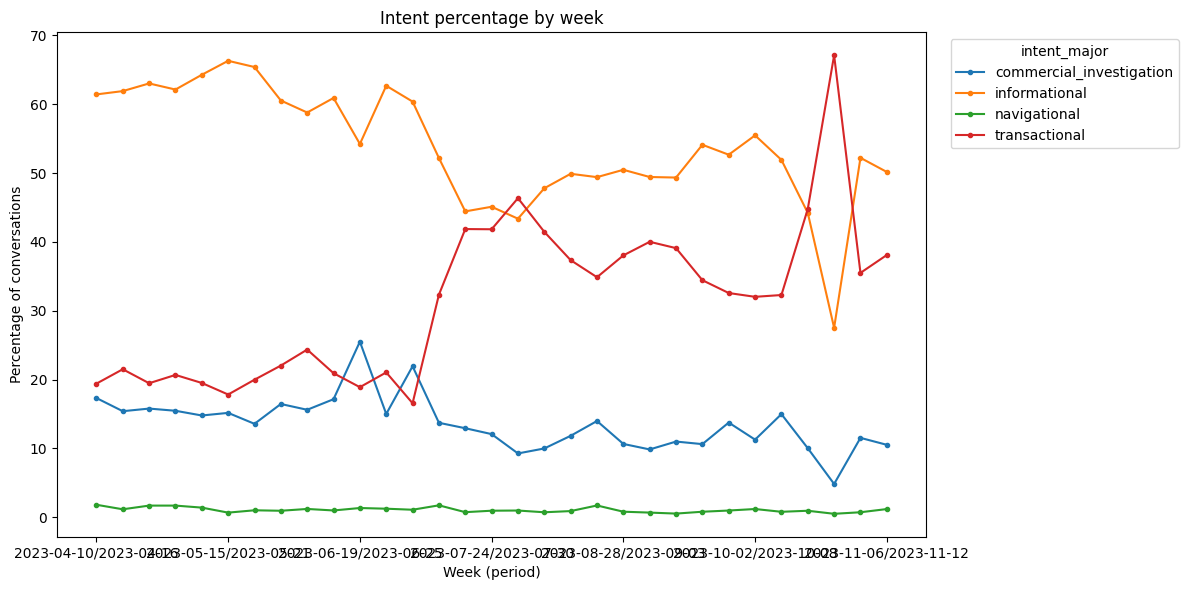

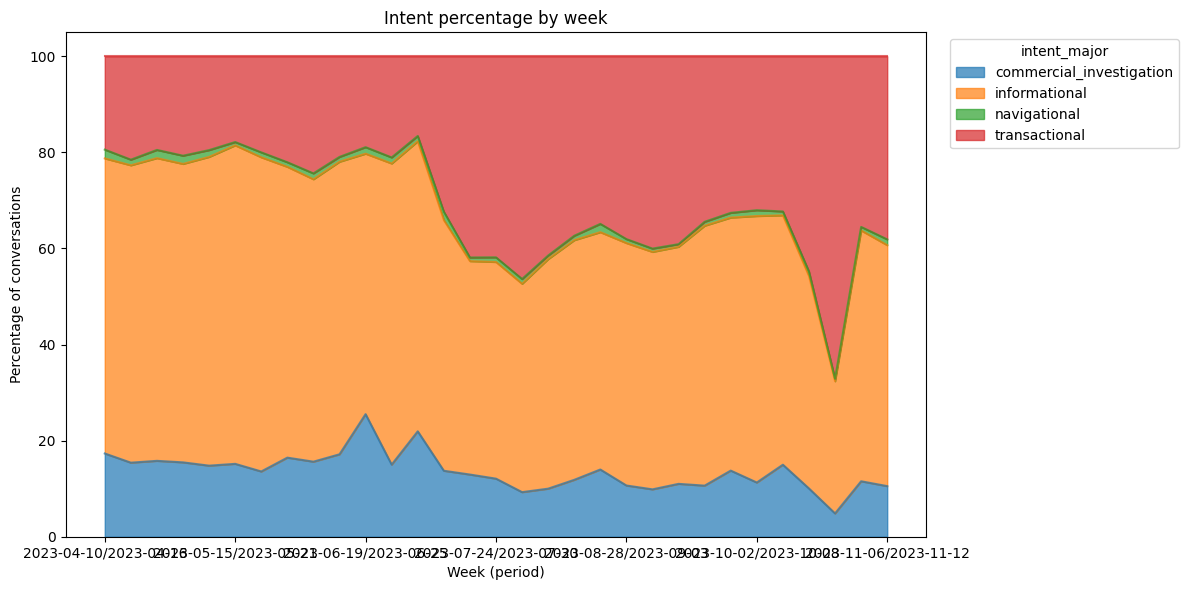

/Users/Larry.Jin/Documents/research/wild_chat/intent_analysis_utils.py:138: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["period"] = pd.to_datetime(out[timestamp_col], utc=True).dt.to_period(freq).astype(str)


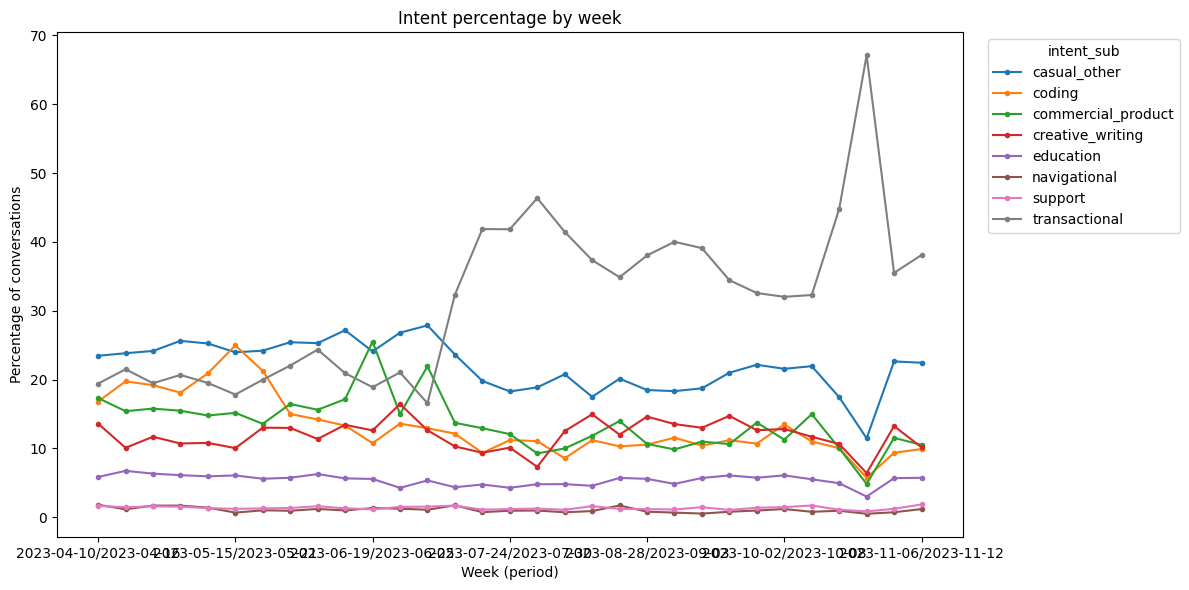

In [5]:
if RUN_WEEKLY_TRENDS and "intent_major" in df.columns:
    import matplotlib.pyplot as plt
    from intent_analysis_utils import (
        weekly_intent_percentages,
        plot_weekly_intent_percentages,
    )

    weekly_pct = weekly_intent_percentages(df, label_col="intent_major", timestamp_col="timestamp", freq="W")
    plot_weekly_intent_percentages(weekly_pct, label_col="intent_major", events=EVENT_DATES, stacked=False)
    plt.show()

    # Stacked area (major intents)
    plot_weekly_intent_percentages(weekly_pct, label_col="intent_major", events=EVENT_DATES, stacked=True)
    plt.show()

    # Sub-category trends (line plot)
    weekly_pct_sub = weekly_intent_percentages(df, label_col="intent_sub", timestamp_col="timestamp", freq="W")
    plot_weekly_intent_percentages(weekly_pct_sub, label_col="intent_sub", events=EVENT_DATES, stacked=False)
    plt.show()
else:
    print("RUN_WEEKLY_TRENDS is False or no intent_major; skipping weekly trends.")

## Within-week: percentage by day of week

How intent share varies by weekday (Mon–Sun) within each week; heatmap for one intent and typical-week profile.

/Users/Larry.Jin/Documents/research/wild_chat/intent_analysis_utils.py:244: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["period"] = ts.dt.to_period("W").astype(str)


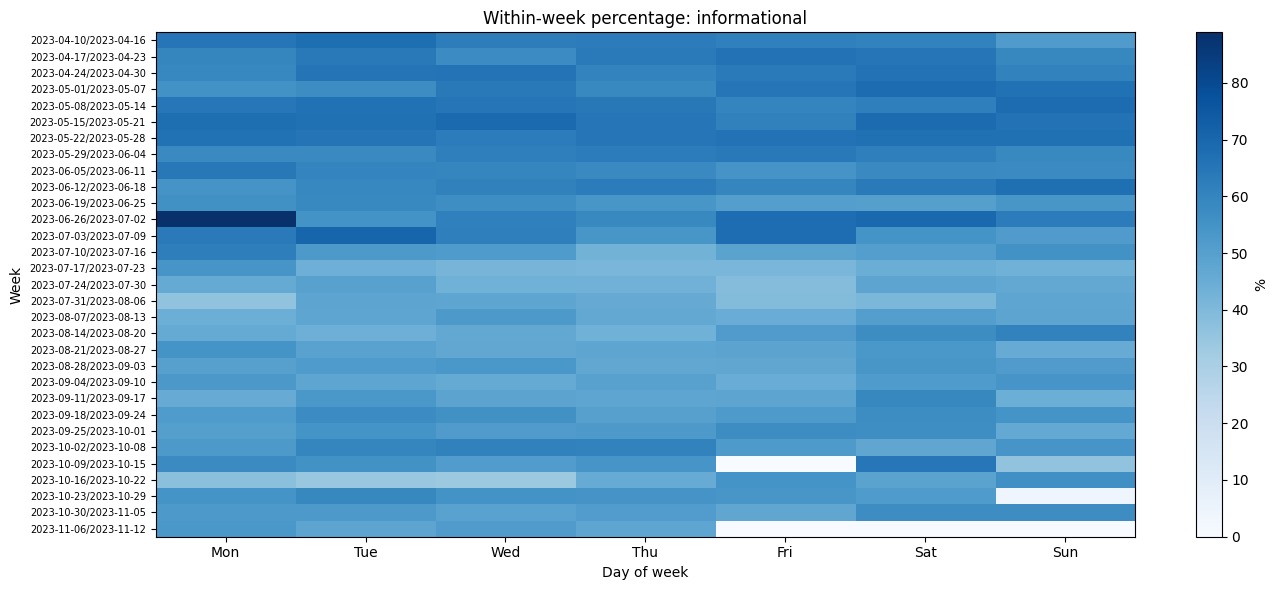

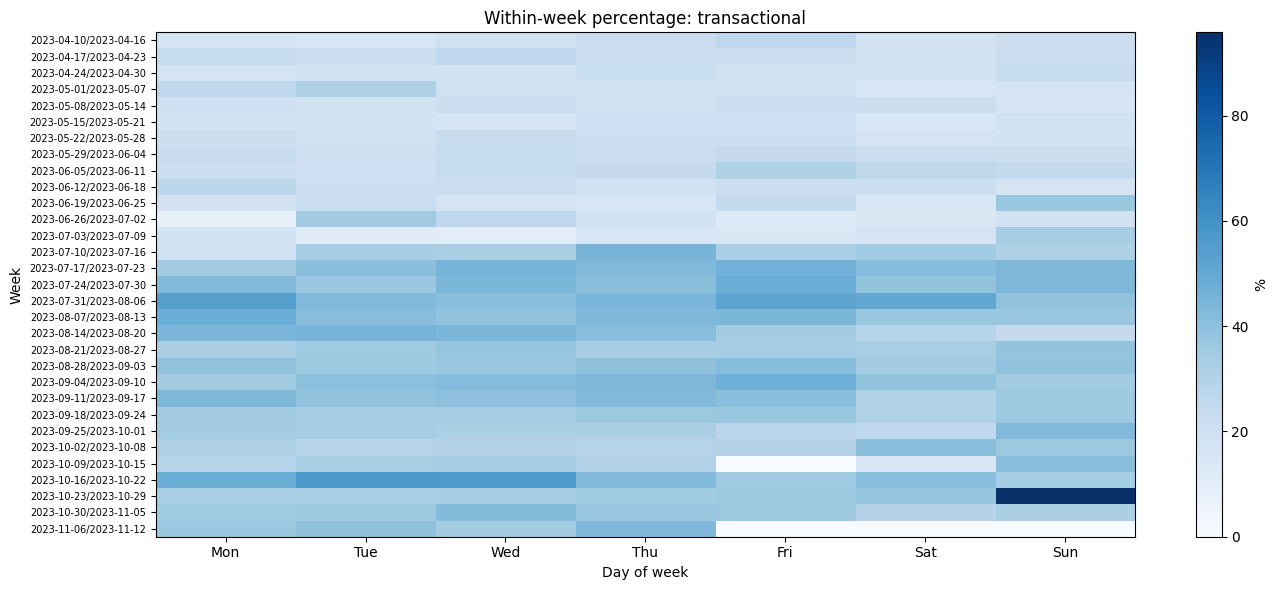

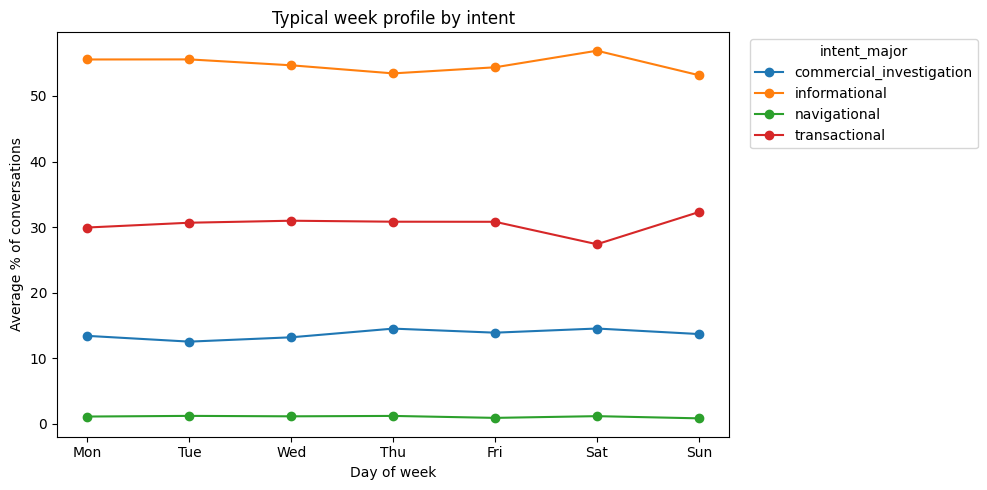

In [6]:
if RUN_WITHIN_WEEK and "intent_major" in df.columns:
    import matplotlib.pyplot as plt
    from intent_analysis_utils import (
        within_week_intent_percentages,
        plot_within_week_heatmap,
        plot_weekday_profile,
    )

    within = within_week_intent_percentages(df, label_col="intent_major", timestamp_col="timestamp")
    # Heatmap for one major intent (e.g. informational)
    for intent in df["intent_major"].dropna().unique()[:2]:
        plot_within_week_heatmap(within, label_value=intent, label_col="intent_major")
        plt.show()
    # Typical week profile (average % by weekday)
    plot_weekday_profile(within, label_col="intent_major")
    plt.show()
else:
    print("RUN_WITHIN_WEEK is False or no intent_major; skipping within-week.")

## Hour-of-day trends

Distribution by **hour (UTC)**. Dataset has no user location; timestamps are UTC. Set `TIMEZONE` (e.g. `"US/Pacific"`) to plot by assumed local hour for illustration only.

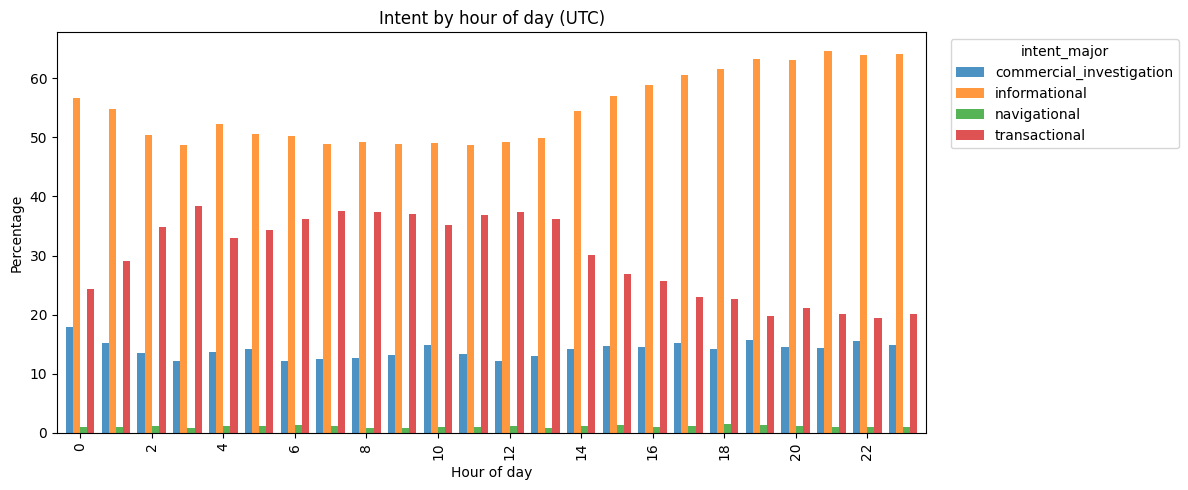

In [7]:
if RUN_HOUR_TRENDS and "intent_major" in df.columns:
    import matplotlib.pyplot as plt
    from intent_analysis_utils import (
        hourly_intent_percentages,
        plot_hourly_intent_distribution,
    )

    # By hour UTC
    hourly_utc = hourly_intent_percentages(df, label_col="intent_major", timestamp_col="timestamp", tz=None)
    plot_hourly_intent_distribution(hourly_utc, label_col="intent_major", value_col="pct", title_suffix="(UTC)")
    plt.show()

    if TIMEZONE:
        hourly_tz = hourly_intent_percentages(df, label_col="intent_major", timestamp_col="timestamp", tz=TIMEZONE)
        plot_hourly_intent_distribution(hourly_tz, label_col="intent_major", value_col="pct", title_suffix=f"(assumed {TIMEZONE})")
        plt.show()
else:
    print("RUN_HOUR_TRENDS is False or no intent_major; skipping hour-of-day.")